# 얼굴 스티커

# import

In [1]:
import sys, os
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
import requests
from io import BytesIO  # binary 파일 입출력

def cv2_imshow(image):
    cv2.imshow('image', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    for _ in range(5):
        cv2.waitKey(1)

def plt_imshow(image, axis=True):  # OpenCV 이미지를 matplotlib 으로 출력하기
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis(axis)
    plt.show()        
    

In [2]:
base_path = r"/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/catcam"

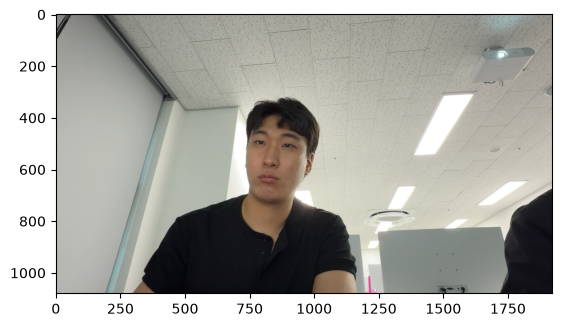

In [4]:
# 한장 가져오기
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print('Camera open failed!')
    sys.exit()

# 한장만 읽기
ret, frame = cap.read()

# 어떤 이미지인지 확인해보기
plt_imshow(frame)
cap.release()


In [5]:
# 사전학습된 모델 과 설정 파일
model = os.path.join(base_path, 'opencv_face_detector_uint8.pb')
config = os.path.join(base_path, 'opencv_face_detector.pbtxt')

In [6]:
# OpenCV 5 부터는 dnn 모듈에 새 엔진 시스템(ENGINE_AUTO/ENGINE_CLASSIC/ENGINE_NEW/ENGINE_ORT)이 생겼다.
# 이 모델은 PriorBox/DetectionOutput 같은 구식 커스텀 레이어를 쓰는 옛날 SSD 그래프이므로,
# OpenCV5 이상이면 항상 기존(classic) 엔진으로 읽도록 명시적으로 고정해 둔다.
# (OpenCV4 에는 ENGINE_CLASSIC 이 없으므로 이 경우 그냥 기존 방식 그대로 net = cv2.dnn.readNet(model, config) 를 호출한다)

if hasattr(cv2.dnn, 'ENGINE_CLASSIC'):
    net = cv2.dnn.readNet(model, config, engine=cv2.dnn.ENGINE_CLASSIC)
else:
    net = cv2.dnn.readNet(model, config)

net

< cv2.dnn.Net 0x145081810>

In [7]:
net.empty()

False

In [8]:
# 고양이 귀 영상 로딩
# 고양이귀 영상을 불러올때     IMREAD_UNCHANGED 플래그를 옵션으로 주어야 한다. 왜?
# 지금 읽어오는 png 파일의 경우 R.G.B 외에도 Alpha 채널이 존재하는데 이를 그대로 읽어와야 함.

cat = cv2.imread(os.path.join(base_path, 'cat.png'), cv2.IMREAD_UNCHANGED)

cat.shape  # 4채널 (B, G, R, A)

(200, 530, 4)

In [9]:
# 모델 입력 준비
blob = cv2.dnn.blobFromImage(frame, 1, (300, 300), (104, 177, 123))
net.setInput(blob)

# 추론
detect = net.forward()

detect.shape  # (1, 1, 200, 7)  (batch, 더미차원, 검출후보개수, 후보하나당 저장된 7개값)
              #  7개 값 
            #  image_id: 배치 내 이미지 인덱스 . 항상 0
            #   class label:  1=얼굴
            #  confidence: 0.0 ~ 1.0
            #  xmin, ymin, xmax, ymax  :  (0~1로 정규화된 좌표)

(1, 1, 200, 7)

In [10]:
h, w = frame.shape[:2]

In [11]:
detect = detect[0, 0, ...]
detect.shape  # (200, 7)

(200, 7)

In [18]:
def overlay(frame, cat, pos):
    # 합성할 위치(pos) 가 frame 안쪽인 경우만 합성
    if pos[0] < 0 or pos[1] < 0: 
        return

    if pos[0] + cat.shape[1] > frame.shape[1] or pos[1] + cat.shape[0] > frame.shape[0]:
        return

    # 합성항 좌표 (4꼭지점)
    sx = pos[0]
    ex = pos[0] + cat.shape[1]
    sy = pos[1]
    ey = pos[1] + cat.shape[0]

    # img1: 카메라 입력 프레임
    # img2: 고양이 영상 (B, G, R)
    # alpha: 고양이 원본 alpha값은 0 ~ 255 -> 0.0 ~ 1.0으로 변환
    img1 = frame[sy:ey, sx:ex]
    img2 = cat[:, :, 0:3]
    alpha = 1. - (cat[:, :, 3] / 255.)

    # img1에 img2를 합성.  각 채널별로 합성
    img1[:, :, 0] = (img1[:, :, 0] * alpha + img2[:, :, 0] * (1.0 - alpha)).astype(np.uint8)
    img1[:, :, 1] = (img1[:, :, 1] * alpha + img2[:, :, 1] * (1.0 - alpha)).astype(np.uint8)
    img1[:, :, 2] = (img1[:, :, 2] * alpha + img2[:, :, 2] * (1.0 - alpha)).astype(np.uint8)
# 슬라이싱 결과가 대입된 데이터에 값을 변경해서 frame 또한 변경됨

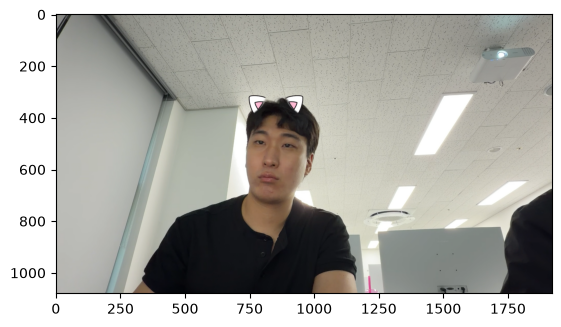

In [19]:
for i in range(detect.shape[0]):  # 얼굴 인식한 후보들
    confidence = detect[i, 2]  # 얼굴일 확률
    if confidence < 0.5:
        break

    # detect한 좌표는 0.0 ~ 0.1 사이 정규화된 값. 이를 원래 좌표로 변환
    x1 = int(detect[i, 3] * w + 0.5)  # 0.5 더해준건 반올림 해주기 위함
    y1 = int(detect[i, 4] * h + 0.5)
    x2 = int(detect[i, 5] * w + 0.5)
    y2 = int(detect[i, 6] * h + 0.5)

    # detect된 얼굴의 크기에 맞추어 고양이 귀 스케일링
    fx = (x2 - x1) / cat.shape[1]  # 비율계산 (폭)
    cat2 = cv2.resize(cat, (0, 0), fx=fx, fy=fx)

    # 얼굴 상단으로부터 대략 1/4 위치
    pos = (x1, y1 - (y2 - y1) // 4)

    # 합성!
    overlay(frame, cat2, pos)

plt_imshow(frame)    


In [21]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print('Camera open failed!')
    sys.exit()

# OpenCV 5 이상이면 구식 SSD 그래프(PriorBox/DetectionOutput 커스텀 레이어)를
# 안정적으로 읽도록 classic 엔진을 명시적으로 고정한다 (OpenCV4 에서는 그냥 기존 방식대로 동작).
if hasattr(cv2.dnn, 'ENGINE_CLASSIC'):
    net = cv2.dnn.readNet(model, config, engine=cv2.dnn.ENGINE_CLASSIC)
else:
    net = cv2.dnn.readNet(model, config)

if net.empty():
    print('Net open failed!')
    sys.exit()

cat = cv2.imread(os.path.join(base_path, 'cat.png'), cv2.IMREAD_UNCHANGED)

if cat is None:
    print('Image open failed!')
    sys.exit()

while True:
    ret, frame = cap.read()

    if not ret:
        break

    blob = cv2.dnn.blobFromImage(frame, 1, (300, 300), (104, 177, 123))
    net.setInput(blob)
    detect = net.forward()

    (h, w) = frame.shape[:2]
    detect = detect[0, 0, :, :]

    for i in range(detect.shape[0]):
        confidence = detect[i, 2]
        if confidence < 0.5:
            break

        x1 = int(detect[i, 3] * w + 0.5)
        y1 = int(detect[i, 4] * h + 0.5)
        x2 = int(detect[i, 5] * w + 0.5)
        y2 = int(detect[i, 6] * h + 0.5)

        fx = (x2 - x1) / cat.shape[1]
        cat2 = cv2.resize(cat, (0, 0), fx=fx, fy=fx)
        pos = (x1, y1 - (y2 - y1) // 4)
        #cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0))

        overlay(frame, cat2, pos)

    cv2.imshow('frame', frame)

    if cv2.waitKey(1) == 27:
        break

cap.release()        
cv2.destroyAllWindows()
for _ in range(5):
    cv2.waitKey(1)